### Imports

In [1]:
import warnings

import torch

from src.engine import compare_models
from src.types.dataset_type import DatasetType
from src.types.filterbank_type import FilterbankType
from src.types.model_type import ModelType

warnings.filterwarnings('ignore', category=UserWarning)

/Users/jackrong/Developer/bio-inspired-sonar-for-underwater-object-detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants

In [2]:
MODELS = [
    (ModelType.CNN, FilterbankType.MEL),
    (ModelType.SNN_DIRECT, FilterbankType.MEL),
]
DATASET = DatasetType.AUDIOMNIST

### Device

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


### Comparison


--- cnn (mel) ---
Loading 30000 spectrograms...
Finished loading spectrograms (8s)
Running benchmark on test set...
 Accuracy: 99.80%
  Macro    — F1: 0.9980 | Precision: 0.9980 | Recall: 0.9980
  Weighted — F1: 0.9980 | Precision: 0.9980 | Recall: 0.9980
  MACs: 2,602,346 | ACs: 0

--- snn_direct (mel) ---
Loading 30000 spectrograms...
Finished loading spectrograms (8s)
Running benchmark on test set...
 Accuracy: 99.70%
  Macro    — F1: 0.9970 | Precision: 0.9970 | Recall: 0.9969
  Weighted — F1: 0.9970 | Precision: 0.9970 | Recall: 0.9970
  MACs: 622,080 | ACs: 2,337,417


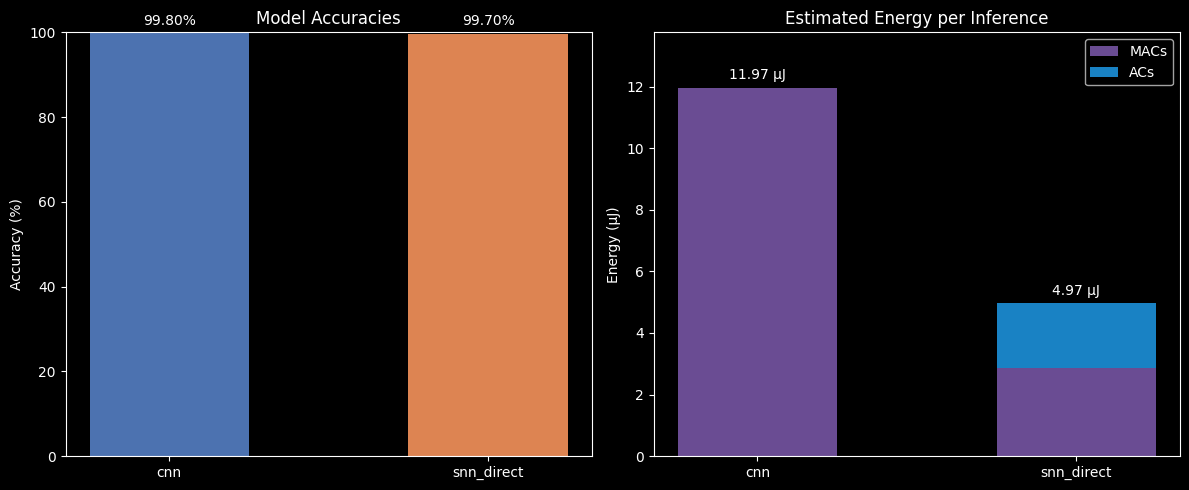

[{'model': 'cnn',
  'dataset': 'audiomnist',
  'filterbank': 'mel',
  'device': 'mps',
  'benchmark': {'accuracy': 99.8,
   'macro_f1': 0.9979885027067112,
   'macro_precision': 0.9980133364587326,
   'macro_recall': 0.9979749187445979,
   'weighted_f1': 0.9979999260209376,
   'weighted_precision': 0.9980110083662488,
   'weighted_recall': 0.998,
   'macs': 2602346,
   'acs': 0}},
 {'model': 'snn_direct',
  'dataset': 'audiomnist',
  'filterbank': 'mel',
  'device': 'mps',
  'benchmark': {'accuracy': 99.7,
   'macro_f1': 0.9969673896503053,
   'macro_precision': 0.9970263992589322,
   'macro_recall': 0.9969247195885653,
   'weighted_f1': 0.9970008435850704,
   'weighted_precision': 0.9970175943505369,
   'weighted_recall': 0.997,
   'macs': 622080,
   'acs': 2337417}}]

In [4]:
compare_models(device, MODELS, DATASET)